<a href="https://colab.research.google.com/github/Jackline-Jebet/kelly-hrp-portfolio/blob/main/Portfolio_Management_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Machine Learning Improvements to Portfolio Construction


Steps 1-7. Kelly optimization, fractional Kelly comparison, K-fold cross-validation, and three
covariance-matrix improvements: denoising, clustering (HRP) and detoning.

**Setup:** `!pip install yfinance -q`

In [ ]:
# =============================================================================
# 0. Configuration
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import KFold

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

TICKERS = ["TSLA", "WMT", "BAC", "GS", "LLY", "MRK", "GOOG", "META", "AAPL", "XOM"]

TRAIN_START, TRAIN_END = "2024-01-01", "2025-09-30"
TEST_START,  TEST_END  = "2025-10-01", "2025-12-31"

TRADING_DAYS = 252
RF_ANNUAL    = 0.045
RF_DAILY     = (1 + RF_ANNUAL) ** (1 / TRADING_DAYS) - 1
CAP          = 0.20                      # Step 1 position limit

print(f"Universe ({len(TICKERS)}): {TICKERS}")
print(f"Training : {TRAIN_START} -> {TRAIN_END}")
print(f"Testing  : {TEST_START} -> {TEST_END}")
print(f"Position cap: {CAP:.0%}  ->  forces at least ceil(1/{CAP}) = "
      f"{int(np.ceil(1/CAP))} positions")

Universe (10): ['TSLA', 'WMT', 'BAC', 'GS', 'LLY', 'MRK', 'GOOG', 'META', 'AAPL', 'XOM']
Training : 2024-01-01 -> 2025-09-30
Testing  : 2025-10-01 -> 2025-12-31
Position cap: 20%  ->  forces at least ceil(1/0.2) = 5 positions


In [ ]:
# =============================================================================
# 1. Price data - real adjusted closes
# =============================================================================
import yfinance as yf

raw = yf.download(TICKERS, start=TRAIN_START, end="2026-01-02",
                  auto_adjust=True, progress=False)
prices = raw["Close"][TICKERS].copy()
prices.index = pd.to_datetime(prices.index).tz_localize(None)

if prices.isna().all().any() or len(prices) < 400:
    raise RuntimeError("Price download incomplete — check tickers, dates, connectivity.")

prices = prices.ffill().dropna()
returns = prices.pct_change().dropna()

train = returns.loc[TRAIN_START:TRAIN_END]
test  = returns.loc[TEST_START:TEST_END]
full  = returns.loc[TRAIN_START:TEST_END]          # used for Step 3 cross-validation

assert not set(train.index) & set(test.index), "train/test overlap"

print(f"Panel   : {prices.shape[0]} days x {prices.shape[1]} tickers")
print(f"Training: {len(train)} obs  ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Testing : {len(test)} obs  ({test.index.min().date()} -> {test.index.max().date()})")
print(f"Full    : {len(full)} obs  (Step 3 uses this)")

stats = pd.DataFrame({
    "Ann. mean":       train.mean() * TRADING_DAYS,
    "Ann. volatility": train.std() * np.sqrt(TRADING_DAYS),
    "Skew":            train.skew(),
    "Excess kurtosis": train.kurt(),
})
print("\nTable 1: In-sample descriptive statistics\n")
stats.round(4)

Panel   : 502 days x 10 tickers
Training: 437 obs  (2024-01-03 -> 2025-09-30)
Testing : 64 obs  (2025-10-01 -> 2025-12-31)
Full    : 501 obs  (Step 3 uses this)

Table 1 — In-sample descriptive statistics



,Ann. mean,Ann. volatility,Skew,Excess kurtosis
Ticker,,,,
TSLA,0.5474,0.6559,0.6708,4.5109
WMT,0.4168,0.2149,0.7228,9.0761
BAC,0.2994,0.2540,-0.6395,8.7764
GS,0.4791,0.2909,0.6864,11.1757
LLY,0.2196,0.3632,-0.3491,8.4283
MRK,-0.1084,0.2532,-0.8841,6.8861
GOOG,0.3699,0.2998,0.2533,5.1544
META,0.5068,0.3775,1.7398,16.3264
AAPL,0.2290,0.2913,0.9972,13.1851


In [ ]:
# =============================================================================
# 2. Kelly optimizer
# =============================================================================
def neg_log_growth(w, X):
    """Negative mean log growth. X is a T x N array of simple returns."""
    g = 1.0 + X @ w
    g = np.maximum(g, 1e-10)          # guard against a wipeout draw
    return -np.mean(np.log(g))

def solve_kelly(X, upper_bound=1.0, n_starts=20, seed=42):
    """Maximize empirical log growth, long-only and fully invested."""
    X = np.asarray(X, float)
    n = X.shape[1]
    if upper_bound * n < 1 - 1e-12:
        raise ValueError(f"cap {upper_bound} infeasible for {n} assets")

    cons   = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    bounds = [(0.0, upper_bound)] * n

    rng    = np.random.default_rng(seed)
    starts = [np.clip(np.repeat(1 / n, n), 0, upper_bound)]
    starts = [s / s.sum() for s in starts]
    while len(starts) < n_starts:
        x = np.clip(rng.dirichlet(np.ones(n)), 0, upper_bound)
        starts.append(x / x.sum())

    best = None
    for x0 in starts:
        r = minimize(neg_log_growth, x0, args=(X,), method="SLSQP",
                     bounds=bounds, constraints=cons,
                     options={"maxiter": 2000, "ftol": 1e-12})
        if r.success and (best is None or r.fun < best.fun):
            best = r
    if best is None:
        raise RuntimeError("optimizer failed from every start")

    w = np.clip(best.x, 0.0, upper_bound)
    assert abs(w.sum() - 1) < 1e-6,       f"budget violated: {w.sum()}"
    assert w.max() <= upper_bound + 1e-9, f"cap violated: {w.max()}"
    return w, -best.fun

w_kelly_free, g_free = solve_kelly(train.values, upper_bound=1.0)
w_kelly_cap,  g_cap  = solve_kelly(train.values, upper_bound=CAP)

table2 = pd.DataFrame({
    "Kelly (no cap)": w_kelly_free,
    f"Kelly ({CAP:.0%} cap)": w_kelly_cap,
}, index=TICKERS)
table2.index.name = "Ticker"

print("Table 2: Kelly portfolio weights\n")
print(table2.round(4).to_string())
print(f"\nDaily log growth rate: uncapped {g_free:.6f}, capped {g_cap:.6f}")
print(f"Annualized growth    : uncapped {np.exp(g_free*TRADING_DAYS)-1:.2%}, "
      f"capped {np.exp(g_cap*TRADING_DAYS)-1:.2%}")
print(f"Growth surrendered to the cap: "
      f"{(np.exp(g_free*TRADING_DAYS)-np.exp(g_cap*TRADING_DAYS)):.2%} per annum")
print(f"\nPositions above 1%: uncapped {(w_kelly_free>0.01).sum()}, "
      f"capped {(w_kelly_cap>0.01).sum()}")
print(f"Positions at the cap: {(w_kelly_cap > CAP - 1e-4).sum()}")

Table 2 - Kelly portfolio weights

        Kelly (no cap)  Kelly (20% cap)
Ticker                                 
TSLA            0.1510           0.2000
WMT             0.0000           0.2000
BAC             0.0000           0.0000
GS              0.3906           0.2000
LLY             0.0000           0.0000
MRK             0.0000           0.0000
GOOG            0.0000           0.2000
META            0.4583           0.2000
AAPL            0.0000           0.0000
XOM             0.0000           0.0000

Daily log growth rate: uncapped 0.001815, capped 0.001705
Annualized growth    : uncapped 57.98%, capped 53.67%
Growth surrendered to the cap: 4.31% per annum

Positions above 1%: uncapped 3, capped 5
Positions at the cap: 5


---
# Step 2: Kelly, Half-Kelly and Double-Kelly Out of Sample

$$r_{p,t}(f) = f \cdot (w^\top r_t) + (1 - f) \cdot r_f$$

Table 3 — Out-of-sample performance and risk, 2025-10-01 to 2025-12-31
(based on the 20%-capped Kelly weights)

                   Half-Kelly (f=0.5)  Kelly (f=1)  Double-Kelly (f=2)
Cumulative return              0.0466       0.0807              0.1442
Ann. volatility                0.0961       0.1921              0.3842
Sharpe ratio                   1.4562       1.4562              1.4562
Max drawdown                  -0.0316      -0.0652             -0.1307
95% VaR (daily)               -0.0091      -0.0184             -0.0370
95% cVaR (daily)              -0.0123      -0.0247             -0.0496
Ann. growth rate               0.1964       0.3572              0.6996

Note: the three Sharpe ratios are identical because excess return scales linearly with the Kelly fraction. Growth rate, drawdown and cVaR are what separate them.


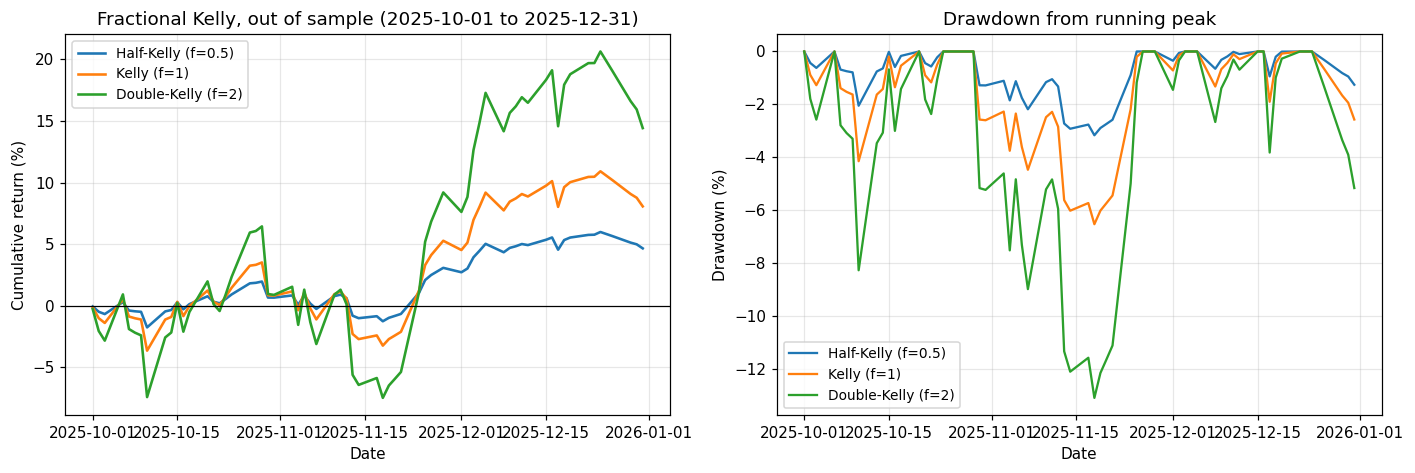

In [ ]:
# =============================================================================
# 3. Fractional Kelly - out-of-sample performance and risk
# =============================================================================
def levered_returns(X, w, f, rf_daily=RF_DAILY):
    """Fractional Kelly: f in the risky portfolio, (1-f) at the risk-free rate."""
    return f * (np.asarray(X) @ w) + (1 - f) * rf_daily

def performance(r, rf_daily=RF_DAILY, alpha=0.05):
    """Cumulative return, volatility, Sharpe, max drawdown, 95% cVaR, growth rate."""
    r = np.asarray(r, float)
    wealth = np.cumprod(1 + r)
    excess = r - rf_daily
    var_a  = np.quantile(r, alpha)
    tail   = r[r <= var_a]
    return {
        "Cumulative return":  wealth[-1] - 1,
        "Ann. volatility":    r.std(ddof=1) * np.sqrt(TRADING_DAYS),
        "Sharpe ratio":       excess.mean() / excess.std(ddof=1) * np.sqrt(TRADING_DAYS),
        "Max drawdown":       (wealth / np.maximum.accumulate(wealth) - 1).min(),
        "95% VaR (daily)":    var_a,
        "95% cVaR (daily)":   tail.mean() if len(tail) else np.nan,
        "Ann. growth rate":   np.exp(np.mean(np.log(np.maximum(1 + r, 1e-10)))
                                     * TRADING_DAYS) - 1,
    }

fractions = {"Half-Kelly (f=0.5)": 0.5, "Kelly (f=1)": 1.0, "Double-Kelly (f=2)": 2.0}

oos_rows, oos_paths = {}, {}
for label, f in fractions.items():
    r = levered_returns(test.values, w_kelly_cap, f)
    oos_rows[label]  = performance(r)
    oos_paths[label] = np.cumprod(1 + r)

table3 = pd.DataFrame(oos_rows)
print(f"Table 3: Out-of-sample performance and risk, {TEST_START} to {TEST_END}")
print(f"(based on the {CAP:.0%}-capped Kelly weights)\n")
print(table3.round(4).to_string())

print("\nNote: the three Sharpe ratios are identical because excess return scales linearly "
      "with the Kelly fraction. Growth rate, drawdown and cVaR are what separate them.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for label, path in oos_paths.items():
    axes[0].plot(test.index, (path - 1) * 100, lw=1.7, label=label)
    dd = (path / np.maximum.accumulate(path) - 1) * 100
    axes[1].plot(test.index, dd, lw=1.5, label=label)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel("Cumulative return (%)"); axes[0].set_xlabel("Date")
axes[0].set_title(f"Fractional Kelly, out of sample ({TEST_START} to {TEST_END})")
axes[0].legend(fontsize=9)
axes[1].set_ylabel("Drawdown (%)"); axes[1].set_xlabel("Date")
axes[1].set_title("Drawdown from running peak")
axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

---
# Step 3: Backtesting with K-Fold Cross-Validation

In [ ]:
# =============================================================================
# 4. Purged K-fold cross-validation
# =============================================================================
def purged_kfold_kelly(X, upper_bound, n_splits=5, embargo=5, fractions=(0.5, 1.0, 2.0)):
    """Contiguous K-fold with purging and embargo, re-solving Kelly on each training set."""
    Xv = np.asarray(X, float)
    kf = KFold(n_splits=n_splits, shuffle=False)
    records, fold_weights = [], {}

    for i, (train_idx, test_idx) in enumerate(kf.split(Xv), start=1):
        lo, hi = test_idx.min(), test_idx.max()
        kept = train_idx[(train_idx < lo - embargo) | (train_idx > hi + embargo)]
        purged = len(train_idx) - len(kept)
        if len(kept) < 60:
            print(f"  fold {i}: only {len(kept)} training obs after purging — skipped")
            continue

        w, g = solve_kelly(Xv[kept], upper_bound=upper_bound, seed=100 + i)
        fold_weights[f"Fold {i}"] = w

        for f in fractions:
            r = levered_returns(Xv[test_idx], w, f)
            m = performance(r)
            m.update({"Fold": i, "Fraction": f, "Train obs": len(kept),
                      "Purged": purged, "Test obs": len(test_idx)})
            records.append(m)
    return pd.DataFrame(records), pd.DataFrame(fold_weights, index=TICKERS)

cv_results, cv_weights = purged_kfold_kelly(full.values, CAP, n_splits=5, embargo=5)

print(f"Purged 5-fold cross-validation over {len(full)} observations "
      f"({full.index.min().date()} to {full.index.max().date()})\n")

cols = ["Fold", "Ann. growth rate", "Sharpe ratio", "Max drawdown", "95% cVaR (daily)"]
for f, label in [(0.5, "Half-Kelly"), (1.0, "Kelly"), (2.0, "Double-Kelly")]:
    sub = cv_results[cv_results["Fraction"] == f]
    print(f"--- {label} ---")
    print(sub[cols].round(4).to_string(index=False))
    print(f"    mean growth {sub['Ann. growth rate'].mean():.4f}  "
          f"sd {sub['Ann. growth rate'].std():.4f}   |   "
          f"mean Sharpe {sub['Sharpe ratio'].mean():.4f}  "
          f"sd {sub['Sharpe ratio'].std():.4f}\n")

table4 = cv_results.groupby("Fraction").agg(
    {"Ann. growth rate": ["mean", "std", "min", "max"],
     "Sharpe ratio": ["mean", "std"],
     "Max drawdown": ["mean", "min"],
     "95% cVaR (daily)": "mean"}).round(4)
print("Table 4: Cross-validated performance by Kelly fraction\n")
print(table4.to_string())

print("\nTable 5: Kelly weights re-estimated on each fold\n")
print(cv_weights.round(3).to_string())
print(f"\nWeight instability across folds - mean absolute deviation per asset:")
print((cv_weights.std(axis=1)).round(4).to_string())

Purged 5-fold cross-validation over 501 observations (2024-01-03 to 2025-12-31)

--- Half-Kelly ---
 Fold  Ann. growth rate  Sharpe ratio  Max drawdown  95% cVaR (daily)
    1            0.1693        1.4184       -0.0237           -0.0096
    2            0.2106        1.7482       -0.0526           -0.0129
    3            0.0644        0.2360       -0.0780           -0.0147
    4            0.2325        1.2061       -0.0755           -0.0207
    5            0.2453        2.1046       -0.0356           -0.0112
    mean growth 0.1844  sd 0.0730   |   mean Sharpe 1.3427  sd 0.7061

--- Kelly ---
 Fold  Ann. growth rate  Sharpe ratio  Max drawdown  95% cVaR (daily)
    1            0.2997        1.4184       -0.0478           -0.0195
    2            0.3921        1.7482       -0.1062           -0.0260
    3            0.0738        0.2360       -0.1540           -0.0295
    4            0.4239        1.2061       -0.1487           -0.0417
    5            0.4733        2.1046       -

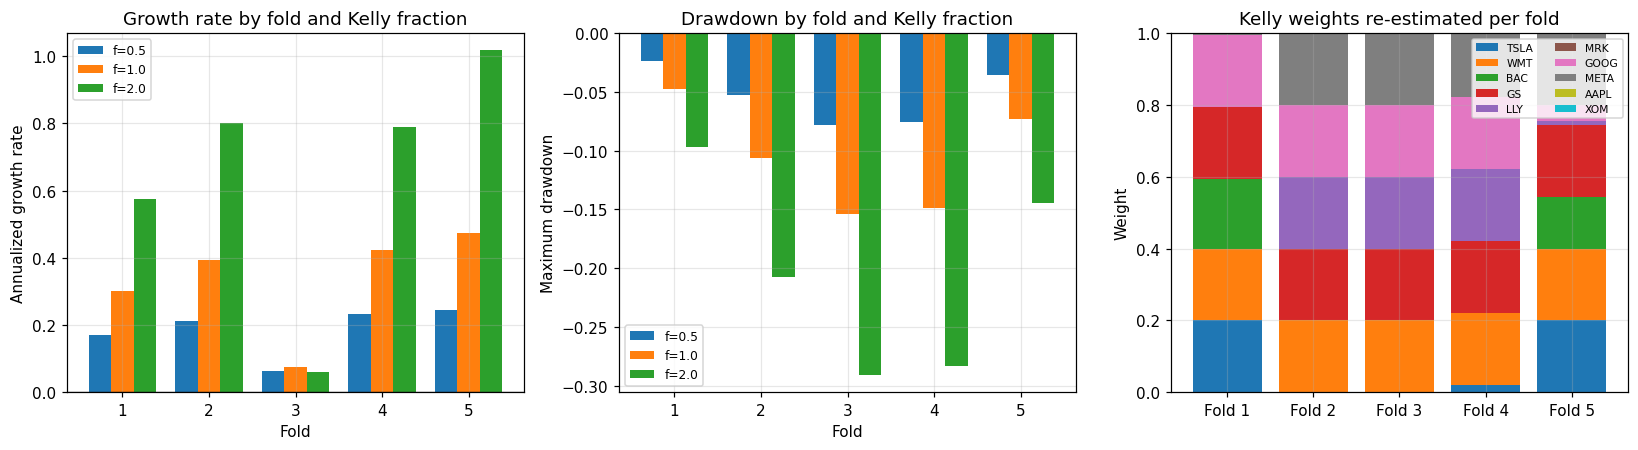

In [ ]:
# =============================================================================
# 5. Cross-validation charts
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

piv = cv_results.pivot(index="Fold", columns="Fraction", values="Ann. growth rate")
piv.columns = [f"f={c}" for c in piv.columns]
piv.plot(kind="bar", ax=axes[0], width=0.78)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel("Annualized growth rate"); axes[0].set_xlabel("Fold")
axes[0].set_title("Growth rate by fold and Kelly fraction")
axes[0].legend(fontsize=8); axes[0].tick_params(axis="x", rotation=0)

piv_dd = cv_results.pivot(index="Fold", columns="Fraction", values="Max drawdown")
piv_dd.columns = [f"f={c}" for c in piv_dd.columns]
piv_dd.plot(kind="bar", ax=axes[1], width=0.78)
axes[1].set_ylabel("Maximum drawdown"); axes[1].set_xlabel("Fold")
axes[1].set_title("Drawdown by fold and Kelly fraction")
axes[1].legend(fontsize=8); axes[1].tick_params(axis="x", rotation=0)

cv_weights.T.plot(kind="bar", stacked=True, ax=axes[2], width=0.8, legend=False)
axes[2].set_ylabel("Weight"); axes[2].set_xlabel("")
axes[2].set_title("Kelly weights re-estimated per fold")
axes[2].tick_params(axis="x", rotation=0)
axes[2].legend(fontsize=7, ncol=2, loc="upper right", bbox_to_anchor=(1.0, 1.0))

plt.tight_layout(); plt.show()

---
# Step 4: Denoising, Clustering and Detoning

## 4.1 Denoising

In [ ]:
# =============================================================================
# 6. Denoising: Marchenko-Pastur eigenvalue clipping
# =============================================================================
def mp_pdf(var, q, n_points=1000):
    """Marchenko-Pastur density for noise variance var and ratio q = T/N."""
    lam_min = var * (1 - np.sqrt(1 / q)) ** 2
    lam_max = var * (1 + np.sqrt(1 / q)) ** 2
    lam = np.linspace(lam_min, lam_max, n_points)
    pdf = q / (2 * np.pi * var * lam) * np.sqrt(np.maximum((lam_max - lam) * (lam - lam_min), 0))
    return pd.Series(pdf, index=lam)

def kde_pdf(obs, bandwidth=0.01, x=None):
    obs = np.asarray(obs).reshape(-1, 1)
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(obs)
    x = (np.unique(obs) if x is None else np.asarray(x)).reshape(-1, 1)
    return pd.Series(np.exp(kde.score_samples(x)), index=x.flatten())

def _mp_error(var, eigenvalues, q, bandwidth):
    theoretical = mp_pdf(float(var), q)
    empirical   = kde_pdf(eigenvalues, bandwidth, x=theoretical.index.values)
    return float(np.sum((empirical - theoretical) ** 2))

def fit_noise_variance(eigenvalues, q, bandwidth=0.01):
    """Fit sigma^2 by minimizing the distance between empirical and MP eigenvalue densities."""
    out = minimize_scalar(_mp_error, args=(eigenvalues, q, bandwidth),
                          bounds=(1e-5, 1 - 1e-5), method="bounded")
    var = out.x
    return var, var * (1 + np.sqrt(1 / q)) ** 2

def cov_to_corr(cov):
    sd = np.sqrt(np.diag(cov))
    return np.clip(cov / np.outer(sd, sd), -1, 1), sd

def corr_to_cov(corr, sd):
    return corr * np.outer(sd, sd)

def denoise_corr(corr, q, bandwidth=0.01):
    """Constant-residual-eigenvalue denoising. Returns the matrix and a diagnostics dict."""
    eig_val, eig_vec = np.linalg.eigh(corr)
    order = eig_val.argsort()[::-1]
    eig_val, eig_vec = eig_val[order], eig_vec[:, order]

    var, lam_max = fit_noise_variance(eig_val, q, bandwidth)
    n_facts = int((eig_val > lam_max).sum())

    clipped = eig_val.copy()
    if n_facts < len(clipped):
        clipped[n_facts:] = clipped[n_facts:].sum() / (len(clipped) - n_facts)

    c = eig_vec @ np.diag(clipped) @ eig_vec.T
    sd_ = np.sqrt(np.diag(c))
    c = c / np.outer(sd_, sd_)
    return np.clip(c, -1, 1), {"sigma2": var, "lambda_max": lam_max,
                                "n_factors": n_facts,
                                "eig_raw": eig_val, "eig_clipped": clipped}

cov_train = train.cov().values * TRADING_DAYS
corr_raw, sd_train = cov_to_corr(cov_train)
q_ratio = train.shape[0] / train.shape[1]

corr_den, diag = denoise_corr(corr_raw, q_ratio)

print(f"q = T/N = {train.shape[0]}/{train.shape[1]} = {q_ratio:.1f}")
print(f"Fitted noise variance sigma^2 : {diag['sigma2']:.4f}")
print(f"Marchenko-Pastur cutoff lambda+: {diag['lambda_max']:.4f}")
print(f"Eigenvalues retained as signal : {diag['n_factors']} of {len(TICKERS)}")
print(f"\nRaw eigenvalues     : {np.round(diag['eig_raw'], 4)}")
print(f"Denoised eigenvalues: {np.round(diag['eig_clipped'], 4)}")
print(f"\nCondition number: raw {np.linalg.cond(corr_raw):.2f} -> "
      f"denoised {np.linalg.cond(corr_den):.2f}")
print(f"Trace preserved : raw {np.trace(corr_raw):.4f}, denoised {np.trace(corr_den):.4f}")

q = T/N = 437/10 = 43.7
Fitted noise variance sigma^2 : 0.8611
Marchenko-Pastur cutoff lambda+: 1.1413
Eigenvalues retained as signal : 3 of 10

Raw eigenvalues     : [3.5508 1.2413 1.1575 0.8456 0.7834 0.6769 0.5937 0.493  0.4485 0.2093]
Denoised eigenvalues: [3.5508 1.2413 1.1575 0.5786 0.5786 0.5786 0.5786 0.5786 0.5786 0.5786]

Condition number: raw 16.96 -> denoised 6.97
Trace preserved : raw 10.0000, denoised 10.0000


First eigenvector explains 34.7% of total correlation variance

Mean off-diagonal correlation:
  raw      0.2594
  denoised 0.2572
  detoned  -0.1060

Smallest eigenvalues:
  raw      [0.20932827 0.44849867]
  denoised [0.49742801 0.54894173]
  detoned  [4.74585334e-16 6.84325644e-01]

Condition number: raw 1.70e+01, denoised 6.97e+00, detoned 3.72e+15

The detoned matrix is singular by construction - removing one eigenvector leaves rank N-1. It is safe for HRP, which never inverts, and must not be given to an optimizer that does.


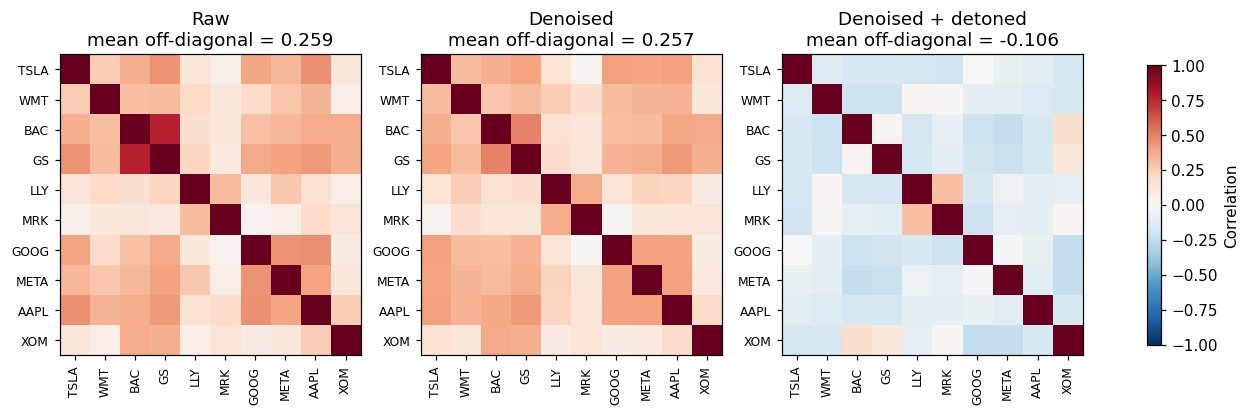

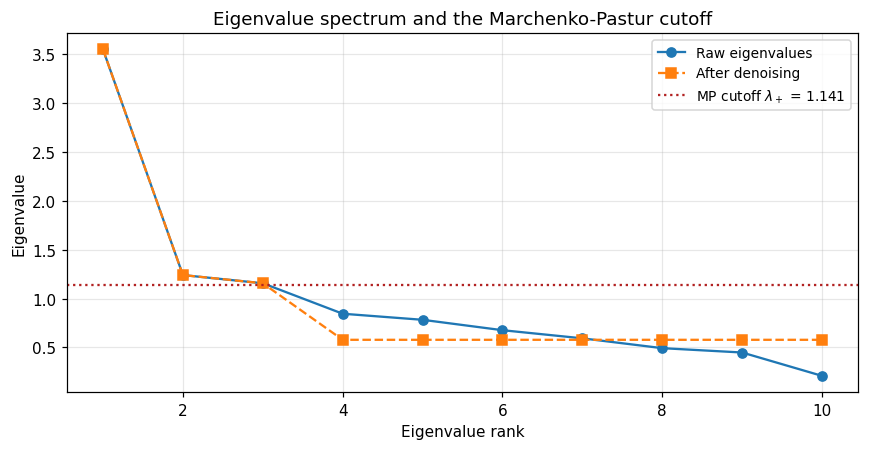

In [ ]:
# =============================================================================
# 7. Detoning: remove the market eigenvector
# =============================================================================
def detone_corr(corr, n_market=1):
    """Remove the largest n_market eigenvectors and rescale to a correlation matrix."""
    eig_val, eig_vec = np.linalg.eigh(corr)
    order = eig_val.argsort()[::-1]
    eig_val, eig_vec = eig_val[order], eig_vec[:, order]

    market = eig_vec[:, :n_market] @ np.diag(eig_val[:n_market]) @ eig_vec[:, :n_market].T
    c = corr - market
    sd_ = np.sqrt(np.diag(c))
    c = c / np.outer(sd_, sd_)
    return np.clip(c, -1, 1), eig_val[:n_market].sum() / eig_val.sum()

corr_det, market_share = detone_corr(corr_den, n_market=1)

iu = np.triu_indices(len(TICKERS), 1)
print(f"First eigenvector explains {market_share:.1%} of total correlation variance")
print(f"\nMean off-diagonal correlation:")
print(f"  raw      {corr_raw[iu].mean():.4f}")
print(f"  denoised {corr_den[iu].mean():.4f}")
print(f"  detoned  {corr_det[iu].mean():.4f}")
print(f"\nSmallest eigenvalues:")
print(f"  raw      {np.linalg.eigvalsh(corr_raw)[:2]}")
print(f"  denoised {np.linalg.eigvalsh(corr_den)[:2]}")
print(f"  detoned  {np.linalg.eigvalsh(corr_det)[:2]}")
print(f"\nCondition number: raw {np.linalg.cond(corr_raw):.2e}, "
      f"denoised {np.linalg.cond(corr_den):.2e}, detoned {np.linalg.cond(corr_det):.2e}")
print("\nThe detoned matrix is singular by construction - removing one eigenvector leaves "
      "rank N-1. It is safe for HRP, which never inverts, and must not be given to an "
      "optimizer that does.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, (M, title) in zip(axes, [(corr_raw, "Raw"), (corr_den, "Denoised"),
                                  (corr_det, "Denoised + detoned")]):
    im = ax.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(TICKERS))); ax.set_xticklabels(TICKERS, rotation=90, fontsize=8)
    ax.set_yticks(range(len(TICKERS))); ax.set_yticklabels(TICKERS, fontsize=8)
    ax.set_title(f"{title}\nmean off-diagonal = {M[iu].mean():.3f}")
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.75, label="Correlation")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.2))
idx = np.arange(1, len(TICKERS) + 1)
ax.plot(idx, diag["eig_raw"], "o-", label="Raw eigenvalues")
ax.plot(idx, diag["eig_clipped"], "s--", label="After denoising")
ax.axhline(diag["lambda_max"], color="firebrick", ls=":", lw=1.5,
           label=f"MP cutoff $\\lambda_+$ = {diag['lambda_max']:.3f}")
ax.set_xlabel("Eigenvalue rank"); ax.set_ylabel("Eigenvalue")
ax.set_title("Eigenvalue spectrum and the Marchenko-Pastur cutoff")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Table 6 — HRP weights under three covariance treatments

        HRP (raw)  HRP (denoised)  HRP (denoised+detoned)
Ticker                                                   
TSLA       0.0223          0.0181                  0.0235
WMT        0.2018          0.2090                  0.1683
BAC        0.0655          0.0758                  0.1282
GS         0.0499          0.0577                  0.0806
LLY        0.0604          0.0685                  0.0464
MRK        0.1243          0.1409                  0.1064
GOOG       0.1069          0.1006                  0.1123
META       0.0524          0.0548                  0.0704
AAPL       0.1221          0.0859                  0.0916
XOM        0.1944          0.1886                  0.1724

Weight sums: {'HRP (raw)': 1.0, 'HRP (denoised)': 1.0, 'HRP (denoised+detoned)': 1.0}

Cluster ordering (raw)     : ['WMT', 'XOM', 'META', 'BAC', 'GS', 'TSLA', 'GOOG', 'AAPL', 'LLY', 'MRK']
Cluster ordering (detoned) : ['AAPL', 'WMT', 'LLY', 'MRK

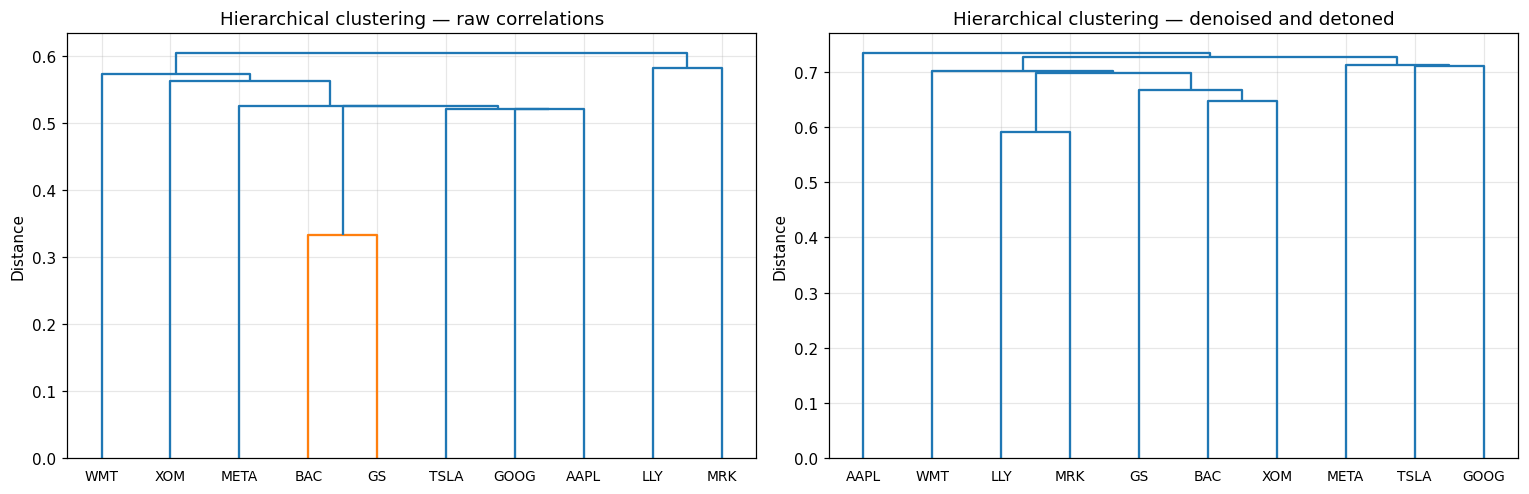

In [ ]:
# =============================================================================
# 8. Hierarchical Risk Parity
# =============================================================================
def correlation_distance(corr):
    return np.sqrt(np.clip((1 - corr) / 2, 0, 1))

def quasi_diagonalize(link):
    """Reorder assets so that similar ones sit adjacent (Lopez de Prado 2016)."""
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    n_items = link[-1, 3]
    while sort_ix.max() >= n_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df = sort_ix[sort_ix >= n_items]
        i, j = df.index, df.values
        sort_ix[i] = link[j - n_items, 0]
        sort_ix = pd.concat([sort_ix, pd.Series(link[j - n_items, 1], index=i + 1)]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()

def inverse_variance_weights(cov):
    ivp = 1.0 / np.diag(cov)
    return ivp / ivp.sum()

def cluster_variance(cov, items):
    sub = cov[np.ix_(items, items)]
    w = inverse_variance_weights(sub).reshape(-1, 1)
    return float((w.T @ sub @ w).item())

def recursive_bisection(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    clusters = [sort_ix]
    while len(clusters) > 0:
        clusters = [c[j:k] for c in clusters
                    for j, k in ((0, len(c) // 2), (len(c) // 2, len(c))) if len(c) > 1]
        for i in range(0, len(clusters), 2):
            c0, c1 = clusters[i], clusters[i + 1]
            v0, v1 = cluster_variance(cov, c0), cluster_variance(cov, c1)
            alpha = 1 - v0 / (v0 + v1)
            w[c0] *= alpha
            w[c1] *= 1 - alpha
    return w

def hrp_portfolio(cov, corr, tickers):
    """HRP weights. Requires no matrix inversion, so a singular covariance is fine."""
    dist = correlation_distance(corr)
    link = linkage(squareform(dist, checks=False), method="single")
    order = quasi_diagonalize(link)
    w = recursive_bisection(np.asarray(cov, float), order)
    weights = pd.Series(w.values, index=[tickers[i] for i in w.index]).reindex(tickers)
    return weights.values, link, order

cov_den = corr_to_cov(corr_den, sd_train)
cov_det = corr_to_cov(corr_det, sd_train)

w_hrp_raw, link_raw, order_raw = hrp_portfolio(cov_train, corr_raw, TICKERS)
w_hrp_den, link_den, order_den = hrp_portfolio(cov_den,   corr_den, TICKERS)
w_hrp_det, link_det, order_det = hrp_portfolio(cov_det,   corr_det, TICKERS)

table6 = pd.DataFrame({
    "HRP (raw)":               w_hrp_raw,
    "HRP (denoised)":          w_hrp_den,
    "HRP (denoised+detoned)":  w_hrp_det,
}, index=TICKERS)
table6.index.name = "Ticker"

print("Table 6: HRP weights under three covariance treatments\n")
print(table6.round(4).to_string())
print(f"\nWeight sums: {table6.sum().round(6).to_dict()}")
print(f"\nCluster ordering (raw)     : {[TICKERS[i] for i in order_raw]}")
print(f"Cluster ordering (detoned) : {[TICKERS[i] for i in order_det]}")
print(f"\nEffective number of positions (1 / sum of squared weights):")
for c in table6.columns:
    w = table6[c].values
    print(f"  {c:24s} {1/np.sum(w**2):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
dendrogram(link_raw, labels=TICKERS, ax=axes[0], leaf_font_size=9)
axes[0].set_title("Hierarchical clustering - raw correlations")
axes[0].set_ylabel("Distance")
dendrogram(link_det, labels=TICKERS, ax=axes[1], leaf_font_size=9)
axes[1].set_title("Hierarchical clustering - denoised and detoned")
axes[1].set_ylabel("Distance")
plt.tight_layout(); plt.show()

---
# Step 5: Applying the Improvements

## Design of the comparison

To let denoising and detoning act on the Kelly allocation, we use the second-order approximation to
log growth,

$$g(w) \approx w^\top\mu - \tfrac{1}{2} w^\top \Sigma w,$$



Table 7: Portfolio weights across all treatments

        Equal weight  Kelly (baseline)  Kelly + denoised  HRP (raw)  HRP + denoised  HRP + denoised + detoned
Ticker                                                                                                       
TSLA          0.1000            0.2000            0.2000     0.0223          0.0181                    0.0235
WMT           0.1000            0.2000            0.2000     0.2018          0.2090                    0.1683
BAC           0.1000            0.0000            0.0000     0.0655          0.0758                    0.1282
GS            0.1000            0.2000            0.2000     0.0499          0.0577                    0.0806
LLY           0.1000            0.0000            0.0000     0.0604          0.0685                    0.0464
MRK           0.1000            0.0000            0.0000     0.1243          0.1409                    0.1064
GOOG          0.1000            0.2000            0.2000     0.1069   

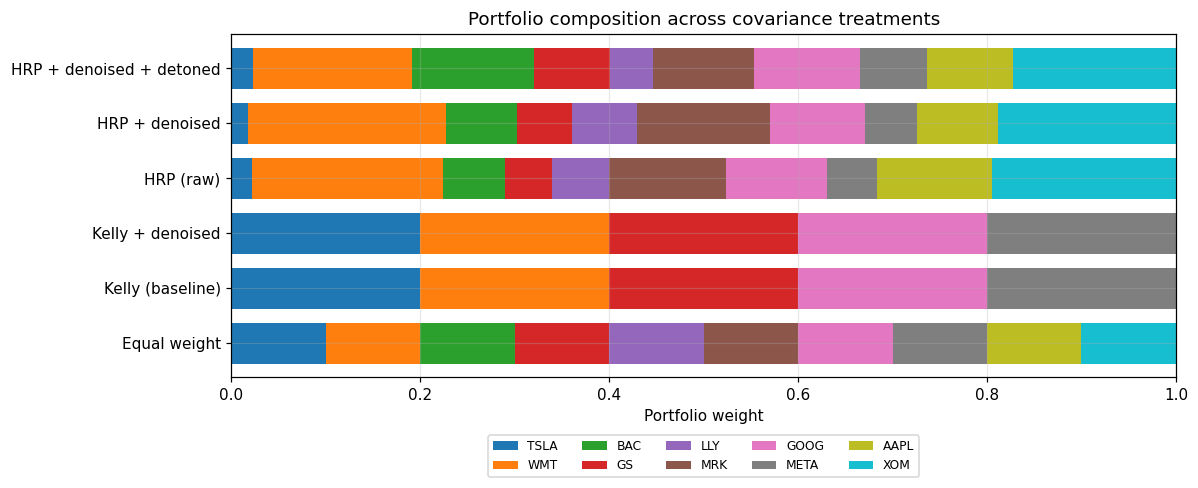

In [ ]:
# =============================================================================
# 9. Building the portfolio set
# =============================================================================
def gaussian_kelly(mu_ann, Sigma_ann, upper_bound=1.0, n_starts=20, seed=7):
    """Maximize w'mu - 0.5 w'Sigma w, the second-order approximation to log growth."""
    mu_ann, Sigma_ann = np.asarray(mu_ann, float), np.asarray(Sigma_ann, float)
    n = len(mu_ann)
    obj    = lambda w: -(w @ mu_ann - 0.5 * w @ Sigma_ann @ w)
    cons   = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
    bounds = [(0.0, upper_bound)] * n

    rng    = np.random.default_rng(seed)
    starts = [np.clip(np.repeat(1 / n, n), 0, upper_bound)]
    starts = [s / s.sum() for s in starts]
    while len(starts) < n_starts:
        x = np.clip(rng.dirichlet(np.ones(n)), 0, upper_bound)
        starts.append(x / x.sum())

    best = None
    for x0 in starts:
        r = minimize(obj, x0, method="SLSQP", bounds=bounds, constraints=cons,
                     options={"maxiter": 2000, "ftol": 1e-12})
        if r.success and (best is None or r.fun < best.fun):
            best = r
    w = np.clip(best.x, 0.0, upper_bound)
    assert abs(w.sum() - 1) < 1e-6 and w.max() <= upper_bound + 1e-9
    return w

mu_train = train.mean().values * TRADING_DAYS

portfolios = {
    "Equal weight":            np.repeat(1 / len(TICKERS), len(TICKERS)),
    "Kelly (baseline)":        w_kelly_cap,
    "Kelly + denoised":        gaussian_kelly(mu_train, cov_den, CAP),
    "HRP (raw)":               w_hrp_raw,
    "HRP + denoised":          w_hrp_den,
    "HRP + denoised + detoned": w_hrp_det,
}

table7 = pd.DataFrame(portfolios, index=TICKERS)
table7.index.name = "Ticker"
print("Table 7: Portfolio weights across all treatments\n")
print(table7.round(4).to_string())

summary = pd.DataFrame({
    "Sum":                     table7.sum(),
    "Largest weight":          table7.max(),
    "Positions above 1%":      (table7 > 0.01).sum(),
    "Effective N":             1 / (table7 ** 2).sum(),
    "Respects 20% cap":        table7.max() <= CAP + 1e-9,
}).T
print("\nWeight-concentration summary\n")
print(summary.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 4.6))
table7.T.plot(kind="barh", stacked=True, ax=ax, width=0.75)
ax.set_xlabel("Portfolio weight"); ax.set_xlim(0, 1)
ax.set_title("Portfolio composition across covariance treatments")
ax.legend(fontsize=8, ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.15))
plt.tight_layout(); plt.show()

---
# Step 6: Do Multiple Improvements Beat Single Ones?

Every portfolio is evaluated on the out-of-sample quarter using six metrics: cumulative return,
annualized growth rate, Sharpe ratio, Sortino ratio, maximum drawdown and 95% cVaR. Growth rate is
included because it is what Kelly actually maximizes, and Sortino because it penalizes only
downside deviation, which matters for allocations with asymmetric return distributions.

Table 8 — Out-of-sample results, 2025-10-01 to 2025-12-31

                   Equal weight  Kelly (baseline)  Kelly + denoised  HRP (raw)  HRP + denoised  HRP + denoised + detoned
Cumulative return        0.1289            0.0807            0.0807     0.1350          0.1397                    0.1256
Ann. growth rate         0.6119            0.3572            0.3572     0.6463          0.6735                    0.5932
Sharpe ratio             3.3215            1.4562            1.4562     4.3115          4.4216                    3.8715
Sortino ratio            5.2283            2.2336            2.2336     6.8547          7.0584                    6.0215
Ann. volatility          0.1332            0.1921            0.1921     0.1068          0.1079                    0.1106
Max drawdown            -0.0361           -0.0652           -0.0652    -0.0307         -0.0296                   -0.0317
95% cVaR (daily)        -0.0151           -0.0247           -0.0247    -0.0126         -0.0126

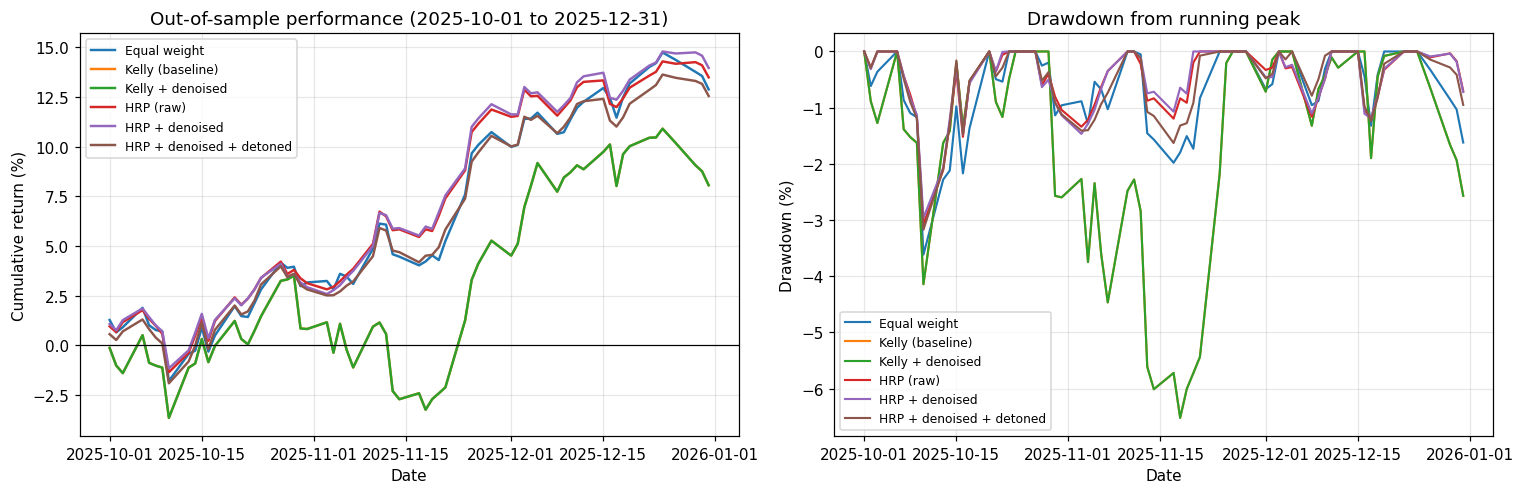

In [ ]:
# =============================================================================
# 10. Out-of-sample comparison across all treatments
# =============================================================================
def sortino(r, rf_daily=RF_DAILY):
    excess = np.asarray(r, float) - rf_daily
    downside = excess[excess < 0]
    dd = downside.std(ddof=1) if len(downside) > 1 else np.nan
    return excess.mean() / dd * np.sqrt(TRADING_DAYS) if dd and dd > 0 else np.nan

results = {}
paths   = {}
for label, w in portfolios.items():
    r = test.values @ w
    m = performance(r)
    m["Sortino ratio"] = sortino(r)
    results[label] = m
    paths[label] = np.cumprod(1 + r)

metric_order = ["Cumulative return", "Ann. growth rate", "Sharpe ratio", "Sortino ratio",
                "Ann. volatility", "Max drawdown", "95% cVaR (daily)"]
table8 = pd.DataFrame(results).reindex(metric_order)
print(f"Table 8 - Out-of-sample results, {TEST_START} to {TEST_END}\n")
print(table8.round(4).to_string())

ranks = pd.DataFrame({
    "Cumulative return": table8.loc["Cumulative return"].rank(ascending=False),
    "Growth rate":       table8.loc["Ann. growth rate"].rank(ascending=False),
    "Sharpe ratio":      table8.loc["Sharpe ratio"].rank(ascending=False),
    "Sortino ratio":     table8.loc["Sortino ratio"].rank(ascending=False),
    "Max drawdown":      table8.loc["Max drawdown"].rank(ascending=False),
    "95% cVaR":          table8.loc["95% cVaR (daily)"].rank(ascending=False),
})
ranks["Average rank"] = ranks.mean(axis=1)
print("\nTable 9 - Rank across metrics (1 = best)\n")
print(ranks.sort_values("Average rank").round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for label, path in paths.items():
    axes[0].plot(test.index, (path - 1) * 100, lw=1.6, label=label)
    dd = (path / np.maximum.accumulate(path) - 1) * 100
    axes[1].plot(test.index, dd, lw=1.4, label=label)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel("Cumulative return (%)"); axes[0].set_xlabel("Date")
axes[0].set_title(f"Out-of-sample performance ({TEST_START} to {TEST_END})")
axes[0].legend(fontsize=8)
axes[1].set_ylabel("Drawdown (%)"); axes[1].set_xlabel("Date")
axes[1].set_title("Drawdown from running peak")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

Table 10 — Cross-validated results across 5 purged folds

                         Ann. growth rate        Sharpe ratio        Max drawdown 95% cVaR (daily)
                                     mean    std         mean    std         mean             mean
Portfolio                                                                                         
Equal weight                       0.3900 0.2797       1.9936 1.7344      -0.0970          -0.0243
HRP (raw)                          0.3415 0.2863       2.3182 2.3141      -0.0749          -0.0192
HRP + denoised                     0.3324 0.2731       2.2144 2.2042      -0.0766          -0.0195
HRP + denoised + detoned           0.3558 0.2546       2.2317 2.0079      -0.0831          -0.0213
Kelly (baseline)                   0.3325 0.1579       1.3427 0.7061      -0.1059          -0.0279
Kelly + denoised                   0.3216 0.1476       1.3049 0.6611      -0.1067          -0.0279

Fold-level Sharpe ratio by portfolio

Portfolio  E

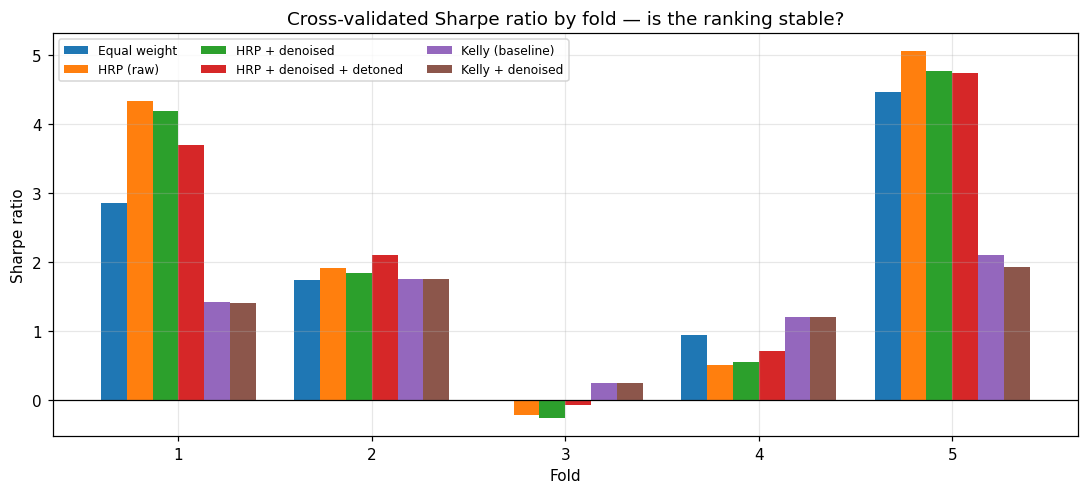

In [ ]:
# =============================================================================
# 11. Cross-validated comparison - is the ranking stable?
# =============================================================================
# A single out-of-sample quarter is 60-odd observations. Before concluding that one
# treatment beats another, we re-run the comparison across the five purged folds.
def cv_compare(X, index, n_splits=5, embargo=5):
    Xv = np.asarray(X, float)
    kf = KFold(n_splits=n_splits, shuffle=False)
    rows = []
    for i, (tr_idx, te_idx) in enumerate(kf.split(Xv), start=1):
        lo, hi = te_idx.min(), te_idx.max()
        kept = tr_idx[(tr_idx < lo - embargo) | (tr_idx > hi + embargo)]
        if len(kept) < 60:
            continue
        tr_df = pd.DataFrame(Xv[kept], columns=TICKERS)

        cov_i  = tr_df.cov().values * TRADING_DAYS
        corr_i, sd_i = cov_to_corr(cov_i)
        q_i = len(kept) / len(TICKERS)
        corr_di, _ = denoise_corr(corr_i, q_i)
        corr_ti, _ = detone_corr(corr_di, 1)
        cov_di = corr_to_cov(corr_di, sd_i)
        cov_ti = corr_to_cov(corr_ti, sd_i)
        mu_i   = tr_df.mean().values * TRADING_DAYS

        w_k, _ = solve_kelly(Xv[kept], CAP, seed=200 + i)
        folds = {
            "Equal weight":             np.repeat(1 / len(TICKERS), len(TICKERS)),
            "Kelly (baseline)":         w_k,
            "Kelly + denoised":         gaussian_kelly(mu_i, cov_di, CAP, seed=200 + i),
            "HRP (raw)":                hrp_portfolio(cov_i,  corr_i,  TICKERS)[0],
            "HRP + denoised":           hrp_portfolio(cov_di, corr_di, TICKERS)[0],
            "HRP + denoised + detoned": hrp_portfolio(cov_ti, corr_ti, TICKERS)[0],
        }
        for label, w in folds.items():
            r = Xv[te_idx] @ w
            m = performance(r)
            m["Sortino ratio"] = sortino(r)
            m.update({"Fold": i, "Portfolio": label})
            rows.append(m)
    return pd.DataFrame(rows)

cv_all = cv_compare(full.values, full.index)

table10 = cv_all.groupby("Portfolio").agg(
    {"Ann. growth rate": ["mean", "std"],
     "Sharpe ratio": ["mean", "std"],
     "Max drawdown": "mean",
     "95% cVaR (daily)": "mean"}).round(4)
print("Table 10 - Cross-validated results across 5 purged folds\n")
print(table10.to_string())

print("\nFold-level Sharpe ratio by portfolio\n")
print(cv_all.pivot(index="Fold", columns="Portfolio", values="Sharpe ratio").round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4.6))
piv = cv_all.pivot(index="Fold", columns="Portfolio", values="Sharpe ratio")
piv.plot(kind="bar", ax=ax, width=0.8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Sharpe ratio"); ax.set_xlabel("Fold")
ax.set_title("Cross-validated Sharpe ratio by fold — is the ranking stable?")
ax.legend(fontsize=8, ncol=3); ax.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

In [ ]:
# =============================================================================
# 12. Validation checks
# =============================================================================
checks = {
    "At least 10 assets":                      len(TICKERS) >= 10,
    "Training window respected":               train.index.min() >= pd.Timestamp(TRAIN_START)
                                                and train.index.max() <= pd.Timestamp(TRAIN_END),
    "Test window respected":                   test.index.min() >= pd.Timestamp(TEST_START)
                                                and test.index.max() <= pd.Timestamp(TEST_END),
    "No train/test overlap":                   not set(train.index) & set(test.index),
    "Kelly weights sum to 1":                  np.isclose(w_kelly_cap.sum(), 1.0, atol=1e-8),
    "Kelly respects the 20% cap":              w_kelly_cap.max() <= CAP + 1e-9,
    "Kelly long-only":                         (w_kelly_cap >= -1e-9).all(),
    "Uncapped growth >= capped growth":        g_free >= g_cap - 1e-12,
    "Denoising preserves the trace":           np.isclose(np.trace(corr_raw), np.trace(corr_den),
                                                          atol=1e-6),
    "Denoising improves conditioning":         np.linalg.cond(corr_den) <= np.linalg.cond(corr_raw),
    "Detoned matrix is singular":              np.linalg.eigvalsh(corr_det).min() < 1e-8,
    "All HRP weights sum to 1":                all(np.isclose(w.sum(), 1.0, atol=1e-8)
                                                   for w in [w_hrp_raw, w_hrp_den, w_hrp_det]),
    "All HRP weights non-negative":            all((w >= -1e-9).all()
                                                   for w in [w_hrp_raw, w_hrp_den, w_hrp_det]),
    "Fractional Kelly Sharpe ratios equal":    np.allclose(
                                                   [oos_rows[k]["Sharpe ratio"] for k in oos_rows],
                                                   oos_rows["Kelly (f=1)"]["Sharpe ratio"],
                                                   atol=1e-8),
}
for k, v in checks.items():
    print(f"  {'PASS' if v else 'FAIL'}  {k}")
assert all(checks.values()), "one or more validation checks failed"
print("\nAll checks passed.")

  PASS  At least 10 assets
  PASS  Training window respected
  PASS  Test window respected
  PASS  No train/test overlap
  PASS  Kelly weights sum to 1
  PASS  Kelly respects the 20% cap
  PASS  Kelly long-only
  PASS  Uncapped growth >= capped growth
  PASS  Denoising preserves the trace
  PASS  Denoising improves conditioning
  PASS  Detoned matrix is singular
  PASS  All HRP weights sum to 1
  PASS  All HRP weights non-negative
  PASS  Fractional Kelly Sharpe ratios equal

All checks passed.
